# Breast Cancer Classification from Blood Biomarkers

End-to-end ML project predicting breast cancer status from routine blood analysis and anthropometric measurements (Breast Cancer Coimbra dataset, UCI).

Inspired by [OscarW99's applied-ml-series](https://github.com/OscarW99/applied-ml-series/blob/main/ClassicalML1_2_EndToEnd_BreastCancerClassification.ipynb), adapted to a different dataset as a guided learning project.

## Roadmap
1. Get the data
2. Initial exploration & visualization
3. Train/test split
4. Deeper exploration on the training set
5. Prepare the data (imputation, encoding, scaling)
6. Select and train models
7. Fine-tune the best model
8. Feature importances
9. Evaluate on the test set
10. Save the model

---
# 1. Get the Data

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as sk

# Load the dataset
data = pd.read_csv('../data/breast_cancer_coimbra.csv')

# Change values 1 and 2 to 0 and 1 in column 'Classification'
data['Classification'] = data['Classification'].replace({1: 0, 2: 1})
print(data['Classification'].value_counts())

Classification
1    64
0    52
Name: count, dtype: int64


---
# 2. Initial Data Exploration & Visualization

In [32]:
# Display the first few rows of the dataset
print("\nFirst few rows of the dataset:")
print(data.head())

# Dataset information
print("\nDataset information:")
print(data.info())

# Display basic statistics of the dataset
print("\nBasic statistics of the dataset:")
print(data.describe())


First few rows of the dataset:
   Age        BMI  Glucose  ...  Resistin    MCP.1  Classification
0   48  23.500000       70  ...   7.99585  417.114               0
1   83  20.690495       92  ...   4.06405  468.786               0
2   82  23.124670       91  ...   9.27715  554.697               0
3   68  21.367521       77  ...  12.76600  928.220               0
4   86  21.111111       92  ...  10.57635  773.920               0

[5 rows x 10 columns]

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 116 entries, 0 to 115
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             116 non-null    int64  
 1   BMI             116 non-null    float64
 2   Glucose         116 non-null    int64  
 3   Insulin         116 non-null    float64
 4   HOMA            116 non-null    float64
 5   Leptin          116 non-null    float64
 6   Adiponectin     116 non-null    float64
 7   Resist

Now, let's plot some histograms of the 9 numerical features, separated by class (Classification). This will give us a much better idea of which features might be good discriminators.

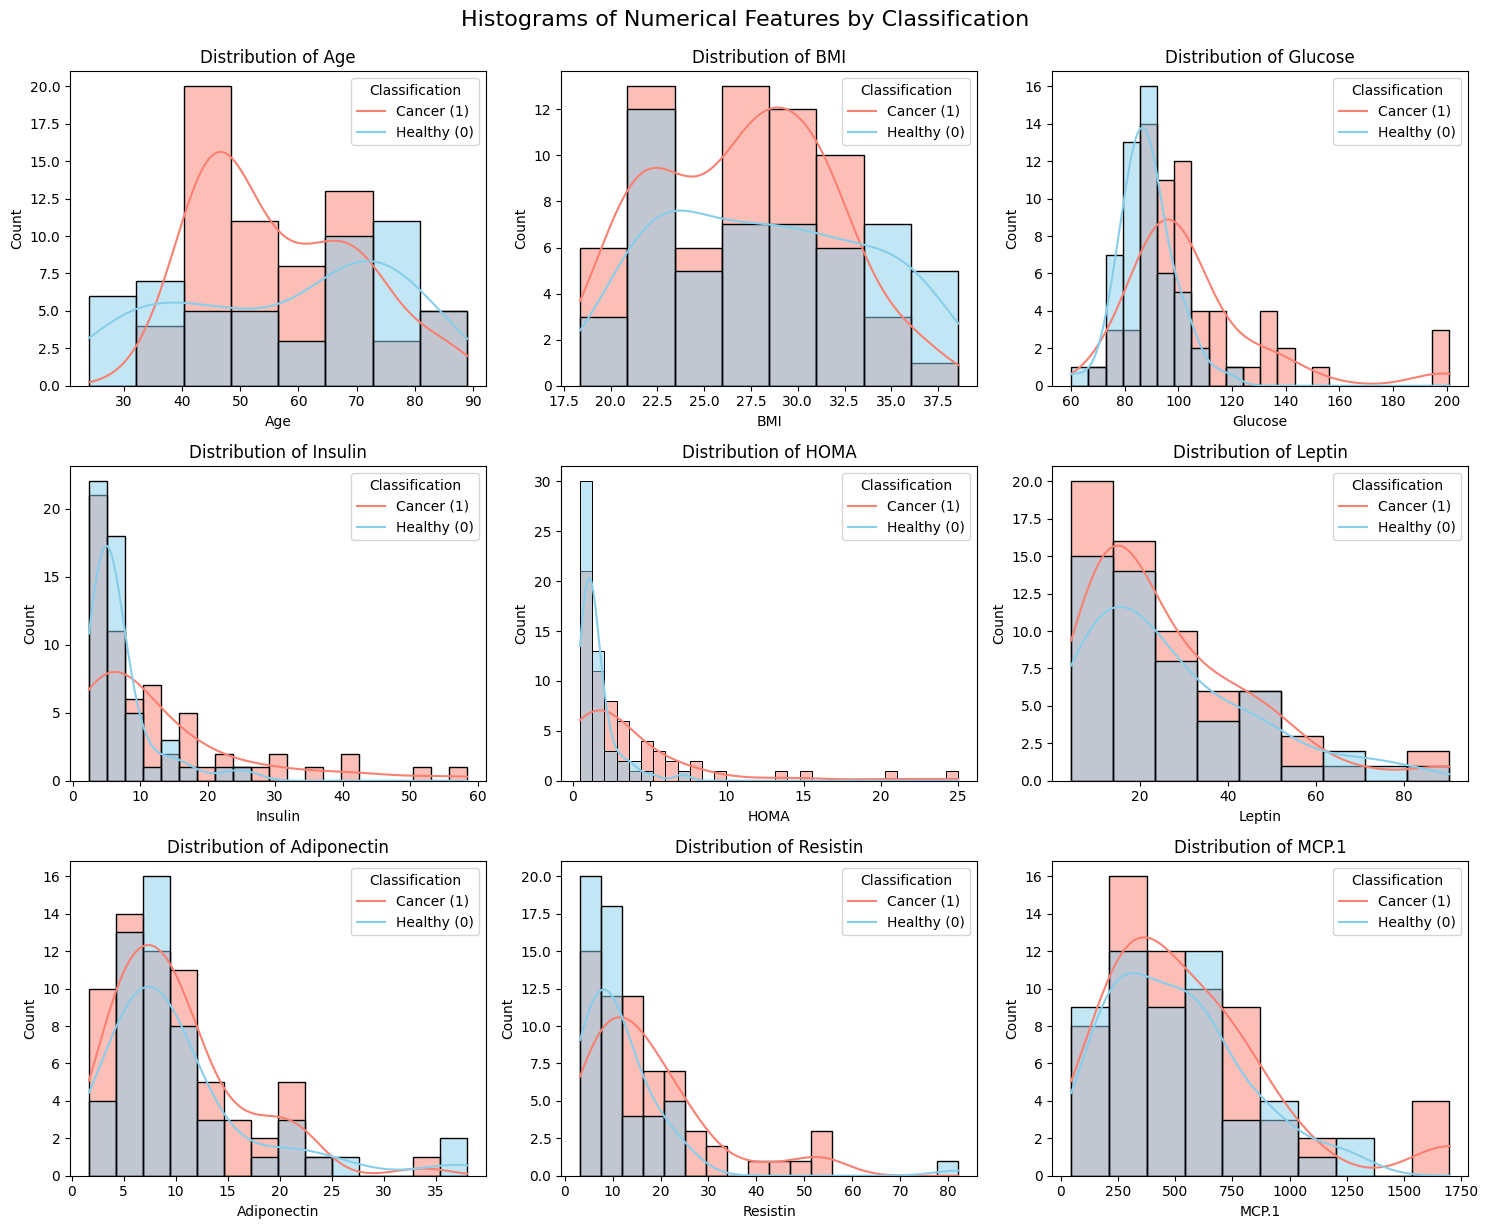

In [33]:
# Get all feature column names except the target column 'Classification'
numerical_features = data.drop(columns=['Classification']).columns

# Plot histograms for each numerical feature
num_features = len(numerical_features)
n_cols = 3
n_rows = (num_features + n_cols - 1) // n_cols  # Ceiling division to determine number of rows needed

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 4))
axes = axes.flatten()  # Flatten the axes array for easy iteration

for i, feature in enumerate(numerical_features):
    sns.histplot(data=data, x=feature, hue='Classification', kde=True, ax=axes[i], palette={0: 'skyblue', 1: 'salmon'})
    axes[i].set_title(f'Distribution of {feature}')
    axes[i].legend(title='Classification', labels=['Cancer (1)', 'Healthy (0)'])

# Remove any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.suptitle('Histograms of Numerical Features by Classification', fontsize=16, y=1.02)
plt.show()


---
# 3. Split into Training and Test Sets

In [34]:
from sklearn.model_selection import train_test_split

# Separate features (X) and target (Y)
X = data.drop(columns=['Classification'])
Y = data['Classification']

# Stratified split 
# test_size=0.2 means 20% of the data will be used for testing, and 80% for training
# random_state ensures reproducibility of the split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=42)

print(f"Training set size: {X_train.shape}, Testing set size: {X_test.shape}")
print("\nTraining set class distribution:")
print(Y_train.value_counts(normalize=True))
print("\nTesting set class distribution:")
print(Y_test.value_counts(normalize=True))

Training set size: (92, 9), Testing set size: (24, 9)

Training set class distribution:
Classification
1    0.554348
0    0.445652
Name: proportion, dtype: float64

Testing set class distribution:
Classification
1    0.541667
0    0.458333
Name: proportion, dtype: float64


---
# 4. Deeper Exploration & Visualization on the Training Set

Now, we work with X_train and Y_train.

**PCA visualization**

Let's use PCA to try and visualize the overall structure of our training data in 2D, colored by diagnosis

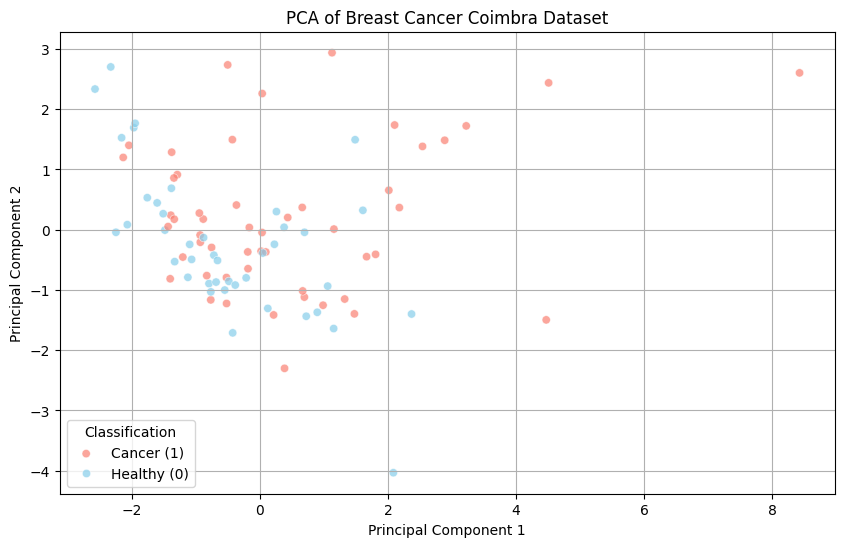

In [35]:
# Use PCA to reduce the dimensionality of the dataset to 2 components for visualization
from sklearn.decomposition import PCA
pca = PCA(n_components=2)

# Scale the features before applying PCA
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform both training and testing data
X_scaled_train = scaler.fit_transform(X_train)
X_scaled_test = scaler.transform(X_test)

# Apply PCA on the scaled training data
X_train_pca = pca.fit_transform(X_scaled_train)

# Create a DataFrame for the PCA results
pca_df = pd.DataFrame(data=X_train_pca, columns=['PCA1', 'PCA2'])

# Add the target variable to the PCA DataFrame
pca_df['Classification'] = Y_train.values

# Plot the PCA results
plt.figure(figsize=(10, 6))
sns.scatterplot(data=pca_df, x='PCA1', y='PCA2', hue='Classification', palette={0: 'skyblue', 1: 'salmon'}, alpha=0.7)
plt.title('PCA of Breast Cancer Coimbra Dataset')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

# Add legend with custom labels
plt.legend(title='Classification', labels=['Cancer (1)', 'Healthy (0)'])
plt.grid()
plt.show()

**Correlation Analysis on Training Data**


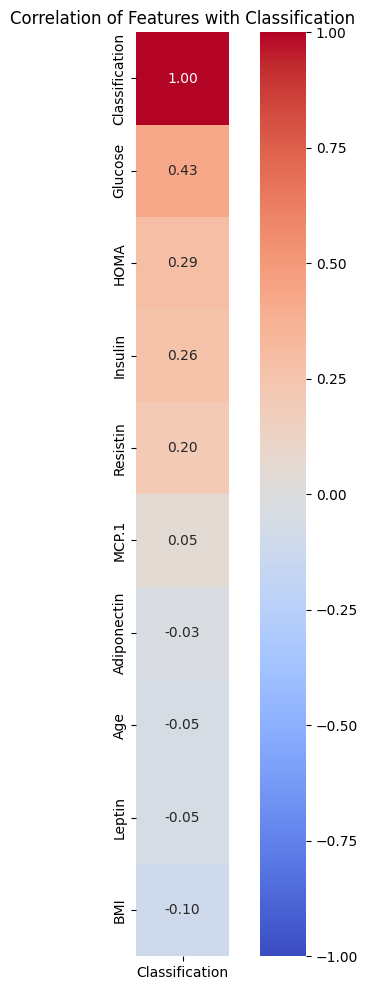

Features most correlated with Classification:
Classification    1.000000
Glucose           0.427595
HOMA              0.290299
Insulin           0.262977
Resistin          0.204195
Name: Classification, dtype: float64


In [36]:
# Add classification back to training dataset for correlation calculation
X_train_with_target = X_train.copy()
X_train_with_target['Classification'] = Y_train.values

# Calculate the correlation matrix
correlation_matrix = X_train_with_target.corr()

# Visualize the correlation matrix using a heatmap
plt.figure(figsize=(8, 12))
sns.heatmap(correlation_matrix[[ 'Classification' ]].sort_values(by='Classification', ascending=False), annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, cbar=True, square=True)
plt.title('Correlation of Features with Classification')
plt.show()

# Print the most correlated features with the target variable 'Classification'
sorted_correlation = correlation_matrix['Classification'].sort_values(ascending=False)
print("Features most correlated with Classification:")
print(sorted_correlation.head(5))


Features like Glucose, HOMA, Insulin and Resistin show positive correlation with Cancer (Classification = 1).

Let's look at the scatter matrix for a few highly correlated features:


Scatter matrix of the top 4 features most correlated with Classification:


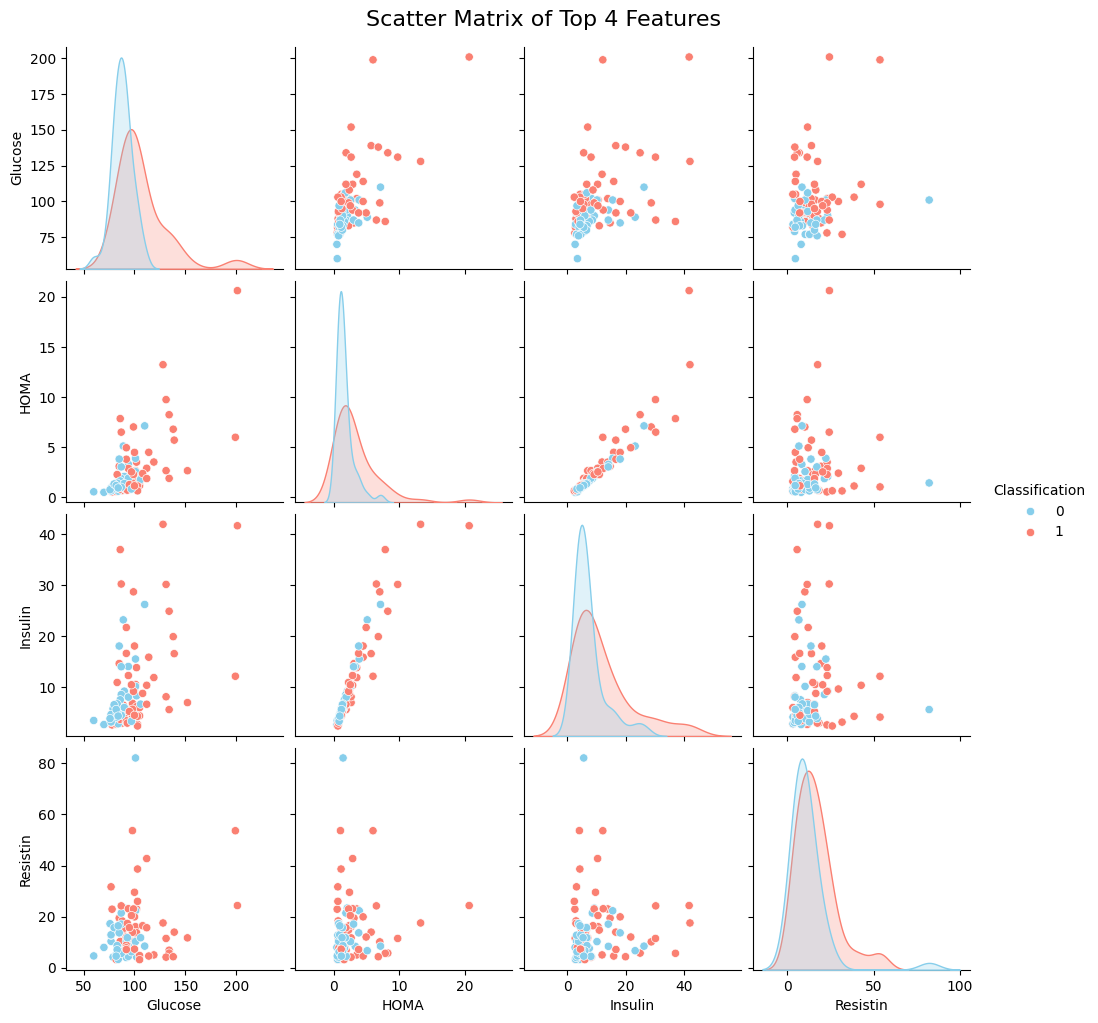

In [37]:
top_features = [f for f in sorted_correlation.index if f != 'Classification'][:4] # Exclude the target variable itself

print("\nScatter matrix of the top 4 features most correlated with Classification:")

if top_features:
    sns.pairplot(X_train_with_target, vars=top_features, hue='Classification', palette={0: 'skyblue', 1: 'salmon'}, diag_kind='kde')
    plt.gcf().suptitle('Scatter Matrix of Top 4 Features', fontsize=16, y=1.02)
    plt.show()
else:
    print("No features found to plot in the scatter matrix.")

There should be seen a slight split seen between the groups in Glucose-HOMA, Glucose-Insulin and HOMA-Insulin

**Box Plots by Diagnosis (Training Data)**

Comparing feature distributions for benign vs. malignant cases using box plots on the training data.

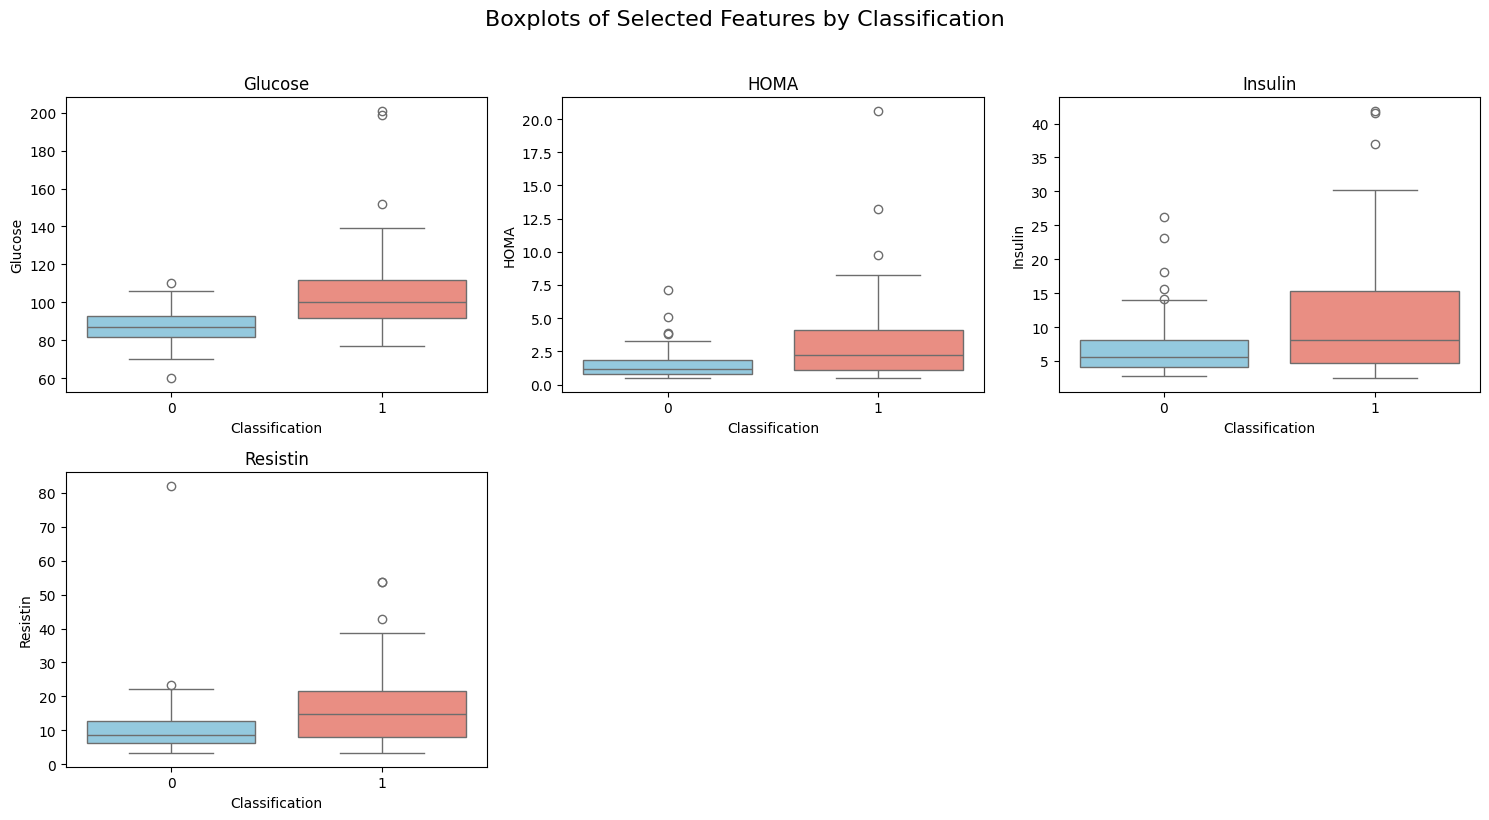

In [38]:
# Select the top 4 features most correlated with the target variable 'Classification'
features_to_use = sorted_correlation.index[1:5]  # Exclude the target variable itself

n_box_features = len(features_to_use)
if n_box_features > 0:
    n_cols_box = min(3, n_box_features)  # Limit to 3 columns for boxplots
    n_rows_box = (n_box_features + n_cols_box - 1) // n_cols_box

    plt.figure(figsize=(n_cols_box * 5, n_rows_box * 4))
    for i, feature in enumerate(features_to_use):
       plt.subplot(n_rows_box, n_cols_box, i + 1)
       sns.boxplot(x='Classification', y=feature, data=X_train_with_target, hue='Classification', legend=False, palette={0: 'skyblue', 1: 'salmon'})
       plt.title(feature)
    plt.suptitle('Boxplots of Selected Features by Classification', fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("No features available for boxplot visualization. Please check the dataset and feature selection process.")

This plot should show some decent separation, with malignant tumors generally having higher values.

---
# 5. Prepare the Data for Machine Learning Algorithms

Time to get the data ready! We need to handle:

-Missing values (our dataset is clean, but we'll show how).

-Categorical features (we don't have any, but we'll show how).

-Feature Scaling (very important!).

We'll use Scikit-Learn's Pipeline to make this process neat and reproducible.

### **Handling Missing Values (Illustrative)**

Our dataset doesn't have missing values. But if it did, SimpleImputer is a good tool.

In [39]:
from sklearn.impute import SimpleImputer

# Create a temporary copy of X_train and introduce some NaN values for demonstration purposes
X_train_temp = X_train.copy()
# Introduce some NaN values randomly in the dataset for demonstration
np.random.seed(42)  # For reproducibility
for i in range(X_train_temp.shape[1]):
    # Randomly select 10% of the rows to set as NaN for each feature
    nan_indices = np.random.choice(X_train_temp.index, size=int(0.1 * X_train_temp.shape[0]), replace=False)
    X_train_temp.loc[nan_indices, X_train_temp.columns[i]] = np.nan

# Check the number of missing values in each feature
missing_values_count = X_train_temp.isnull().sum()
print("\nMissing values in each feature (after introducing NaNs for demonstration):")
print(missing_values_count)

# Initialize the SimpleImputer to replace NaN values with the median of each feature
imputer = SimpleImputer(strategy='median')

# Fit the imputer only in the columns with NaN values
columns_with_nan = missing_values_count[missing_values_count > 0].index
# Transform the columns with NaN values using the fitted imputer
X_train_temp[columns_with_nan] = imputer.fit_transform(X_train_temp[columns_with_nan])

print("\nMissing values after imputation:")
print(X_train_temp.isnull().sum())
print("\nImputed training data (first few rows):")
print(X_train_temp.head())
print("\nImputation completed. The training data is now free of missing values.")


Missing values in each feature (after introducing NaNs for demonstration):
Age            9
BMI            9
Glucose        9
Insulin        9
HOMA           9
Leptin         9
Adiponectin    9
Resistin       9
MCP.1          9
dtype: int64

Missing values after imputation:
Age            0
BMI            0
Glucose        0
Insulin        0
HOMA           0
Leptin         0
Adiponectin    0
Resistin       0
MCP.1          0
dtype: int64

Imputed training data (first few rows):
      Age        BMI  Glucose  ...  Adiponectin  Resistin     MCP.1
85   59.0  29.666548     85.0  ...      7.28287  19.46324  1698.440
2    82.0  23.124670     91.0  ...     22.43204   9.27715   554.697
82   48.0  32.461911     99.0  ...     21.57000  10.15726   738.034
101  66.0  26.562500     89.0  ...      8.42996  10.37518   269.487
4    86.0  21.111111     92.0  ...      4.81924  10.57635   773.920

[5 rows x 9 columns]

Imputation completed. The training data is now free of missing values.


### **Handling Categorical Attributes (Illustrative)**
We don't have categorical features here. But if we did, like tumor_grade ('G1', 'G2', 'G3'), we'd use OneHotEncoder.

In [40]:
from sklearn.preprocessing import OneHotEncoder

# Create dummy categorical data for illustration
# Make sure the index aligns if you were to merge this back, using X_train_temp.index
if len(X_train_temp) > 5:
    X_train_cat_example = pd.DataFrame({'tumor_grade': ['low', 'medium', 'high', 'medium', 'low']}, index=X_train_temp.index[:5])

    # Initialize the OneHotEncoder
    cat_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='first')  # drop='first' to avoid dummy variable trap
    #Fit and transform the categorical data
    X_train_cat_encoded = cat_encoder.fit_transform(X_train_cat_example)

    print("\nEncoded categorical data (first few rows):")
    print(X_train_cat_encoded[:5])
    print("\nFeature names after encoding:")
    print(cat_encoder.get_feature_names_out(['tumor_grade']))
else:
    print("\nNot enough rows in X_train_temp to demonstrate OneHotEncoding. Please ensure there are at least 5 rows.")
print("\nOneHotEncoding completed. The categorical data has been transformed into numerical format.")


Encoded categorical data (first few rows):
[[1. 0.]
 [0. 1.]
 [0. 0.]
 [0. 1.]
 [1. 0.]]

Feature names after encoding:
['tumor_grade_low' 'tumor_grade_medium']

OneHotEncoding completed. The categorical data has been transformed into numerical format.


### **Feature Scaling**

Most ML algorithms work better when numerical features are on a similar scale. We'll use StandardScaler.

In [41]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# We will define the scaler as the first step within each model's pipeline later.
# This ensures that scaling is learned from training data without cross-validation folds.
# For demonstration, let's apply it to X_train to show how it works.
num_pipeline = Pipeline([
    ('scaler', StandardScaler())
])
X_scaled_temp = num_pipeline.fit_transform(X_train)

print("\nScaled training data (first few rows):")
print(X_scaled_temp[:5])

# Convert back to DataFrame for better visualization
X_scaled_temp_df = pd.DataFrame(X_scaled_temp, columns=X_train.columns, index=X_train.index)
print("\nScaled training data as DataFrame (first few rows):")
print(X_scaled_temp_df.head())

# Check the mean and standard deviation of the scaled features
print("\nMean of scaled features (should be close to 0):")
print(X_scaled_temp_df.mean())
print("\nStandard deviation of scaled features (should be close to 1):")
print(X_scaled_temp_df.std())


Scaled training data (first few rows):
[[ 0.41686313  0.36337306 -0.60443177  0.56439351  0.16422255  0.00799447
  -0.42969781  0.42098481  3.3674208 ]
 [ 1.47698335 -0.91419609 -0.33162201 -0.61451425 -0.5325302  -0.43900022
   1.65354644 -0.42033085  0.03725551]
 [-0.64325709  0.90928208  0.03212434  2.19356483  1.49284483  1.02730682
   1.53500266 -0.34763855  0.57106644]
 [ 0.47922314 -0.24281926 -0.4225586  -0.37922047 -0.38972142 -0.59695158
  -0.27195526  0.04567346 -0.79317269]
 [ 1.7264234  -1.30742589 -0.28615372 -0.72472836 -0.6015597  -1.02475279
  -0.76848489 -0.313024    0.67555347]]

Scaled training data as DataFrame (first few rows):
          Age       BMI   Glucose  ...  Adiponectin  Resistin     MCP.1
85   0.416863  0.363373 -0.604432  ...    -0.429698  0.420985  3.367421
2    1.476983 -0.914196 -0.331622  ...     1.653546 -0.420331  0.037256
82  -0.643257  0.909282  0.032124  ...     1.535003 -0.347639  0.571066
101  0.479223 -0.242819 -0.422559  ...    -0.271955  

---
# 6. Select and Train a Model

Now we select and train a few different classification models.

Each model will be part of a pipeline that includes scaling as the first step.

### **Baseline Model: Logistic Regression**

In [42]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score

# Define the pipeline for Logistic Regression
logistic_pipeline = Pipeline([
    ('scaler', StandardScaler()),  # Step 1: Scale the features
    ('classifier', LogisticRegression(solver='liblinear', random_state=42))  # Step 2: Logistic Regression model
])

# Fit the pipeline on the training data
logistic_pipeline.fit(X_train, Y_train)

# Evaluate the model on the training set
Y_train_pred_log_reg = logistic_pipeline.predict(X_train)
train_accuracy_log_reg = accuracy_score(Y_train, Y_train_pred_log_reg)
train_probas_log_reg = logistic_pipeline.predict_proba(X_train)[:, 1]
train_roc_auc_log_reg = roc_auc_score(Y_train, train_probas_log_reg)
print(f"\nLogistic Regression - Training Accuracy: {train_accuracy_log_reg:.4f}")
print(f"Training ROC AUC: {train_roc_auc_log_reg:.4f}")


Logistic Regression - Training Accuracy: 0.7935
Training ROC AUC: 0.8651


### **Decision Tree Classifier

In [43]:
from sklearn.tree import DecisionTreeClassifier

# Define the pipeline for Decision Tree Classifier
decision_tree_pipeline = Pipeline([
    ('scaler', StandardScaler()),  # Step 1: Scale the features
    ('classifier', DecisionTreeClassifier(random_state=42))  # Step 2: Decision Tree model
])
decision_tree_pipeline.fit(X_train, Y_train)

# Evaluate the Decision Tree model on the training set
Y_train_pred_tree = decision_tree_pipeline.predict(X_train)
train_accuracy_tree = accuracy_score(Y_train, Y_train_pred_tree)
train_probas_tree = decision_tree_pipeline.predict_proba(X_train)[:, 1]
train_roc_auc_tree = roc_auc_score(Y_train, train_probas_tree)
print(f"\nDecision Tree - Training Accuracy: {train_accuracy_tree:.4f}")
print(f"Training ROC AUC: {train_roc_auc_tree:.4f}")


Decision Tree - Training Accuracy: 1.0000
Training ROC AUC: 1.0000


### **Better Evaluation Using Cross-Validation**

Cross-validation gives a more robust estimate of model performance on unseen data.

In [44]:
from sklearn.model_selection import cross_val_score

# Cross validation for Logistic Regression
logistic_cv_scores = cross_val_score(logistic_pipeline, X_train, Y_train, cv=5, scoring='roc_auc')
print(f"\nLogistic Regression - Cross-Validation ROC AUC Scores: {logistic_cv_scores}")
print(f"Mean ROC AUC: {logistic_cv_scores.mean():.4f}, Std Dev: {logistic_cv_scores.std():.4f}")

# Cross validation for Decision Tree Classifier
tree_auc_scores = cross_val_score(decision_tree_pipeline, X_train, Y_train, cv=5, scoring='roc_auc')
print(f"\nDecision Tree - Cross-Validation ROC AUC Scores: {tree_auc_scores}")
print(f"Mean ROC AUC: {tree_auc_scores.mean():.4f}, Std Dev: {tree_auc_scores.std():.4f}")


Logistic Regression - Cross-Validation ROC AUC Scores: [0.64772727 0.87777778 0.8125     0.975      0.9625    ]
Mean ROC AUC: 0.8551, Std Dev: 0.1194

Decision Tree - Cross-Validation ROC AUC Scores: [0.49431818 0.67222222 0.5125     0.725      0.7125    ]
Mean ROC AUC: 0.6233, Std Dev: 0.0996


### **Random Forest Classifier**

Random Forest is an ensemble model (multiple decision trees) that often performs well and is more robust to overfitting.

In [45]:
from sklearn.ensemble import RandomForestClassifier
forest_pipeline = Pipeline([
    ('scaler', StandardScaler()),  # Step 1: Scale the features
    ('forest_clf', RandomForestClassifier(n_estimators=100, random_state=42))  # Step 2: Random Forest model
])
forest_auc_scores = cross_val_score(forest_pipeline, X_train, Y_train, cv=5, scoring='roc_auc')
print(f"\nRandom Forest - Cross-Validation ROC AUC Scores: {forest_auc_scores}")
print(f"Mean ROC AUC: {forest_auc_scores.mean():.4f}, Std Dev: {forest_auc_scores.std():.4f}")


Random Forest - Cross-Validation ROC AUC Scores: [0.80113636 0.9        0.725      0.8125     0.9       ]
Mean ROC AUC: 0.8277, Std Dev: 0.0662


---
# 7. Fine-Tune Your Model

Let's assume Random Forest is our most promising model. Now we fine-tune its hyperparameters.

**Grid Search** (GridSearchCV) Tries all combinations of hyperparameters you specify.

In [46]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for Random Forest
param_grid_forest = [
    {'forest_clf__n_estimators': [50, 100, 200],
     'forest_clf__max_depth': [None, 5, 10],
     'forest_clf__max_features': ['sqrt', 'log2'],
     'forest_clf__min_samples_split': [2, 5, 10]}]

# Use the same pipeline structure for Random Forest as defined earlier
forest_pipeline = Pipeline([
    ('scaler', StandardScaler()),  # Step 1: Scale the features
    ('forest_clf', RandomForestClassifier(random_state=42))  # Step 2: Random Forest model
])

# Initialize GridSearchCV for Random Forest
grid_search_forest = GridSearchCV(forest_pipeline, param_grid_forest, cv=5, scoring='roc_auc', return_train_score=True, verbose=1, n_jobs=-1)

# Fit the grid search to the training data
grid_search_forest.fit(X_train, Y_train)

print("\nBest parameters found for Random Forest:")
print(grid_search_forest.best_params_)
print(f"Best CV AUC Score: {grid_search_forest.best_score_:.4f}")

# The best estimator from the grid search
best_forest_model = grid_search_forest.best_estimator_

Fitting 5 folds for each of 54 candidates, totalling 270 fits

Best parameters found for Random Forest:
{'forest_clf__max_depth': 5, 'forest_clf__max_features': 'sqrt', 'forest_clf__min_samples_split': 5, 'forest_clf__n_estimators': 50}
Best CV AUC Score: 0.8482


---
# 8. Feature Importances

Once you have your best model, you can inspect it. For Random Forests, feature importances tell you which features were most influential.


Top 10 Feature Importances (from best Random Forest):
Glucose: 0.2617
Resistin: 0.1435
BMI: 0.1344
Age: 0.1067
HOMA: 0.0922
Insulin: 0.0894
Leptin: 0.0694
MCP.1: 0.0543
Adiponectin: 0.0484


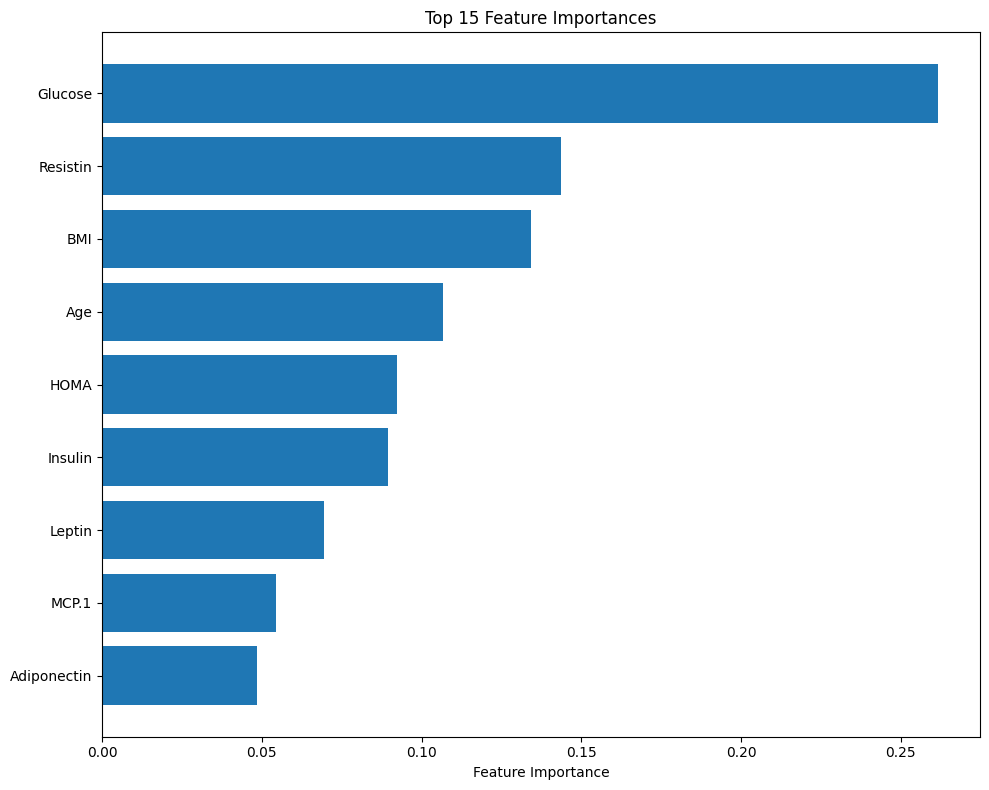

In [47]:
# Let's use the best model from GridSearchCV
final_model_pipeline = best_forest_model # or best_rf_model_rs if you ran RandomizedSearch and it was better

# The RandomForestClassifier is the step named "forest_clf" in our pipeline
final_model_classifier_step = final_model_pipeline.named_steps["forest_clf"]
feature_importances = final_model_classifier_step.feature_importances_

# Get feature names (they are the same as X_train.columns because scaler doesn't change them)
feature_names = X_train.columns

sorted_importances_with_names = sorted(zip(feature_importances, feature_names), reverse=True)

print("\nTop 10 Feature Importances (from best Random Forest):")
for importance, name in sorted_importances_with_names[:10]:
    print(f"{name}: {importance:.4f}")

plt.figure(figsize=(10, 8))
top_n = 15
# Plot horizontal bar chart (easier to read with many features)
# We take top_n and then reverse the list for plotting so the most important is at the top
names_for_plot = [name for imp, name in sorted_importances_with_names[:top_n]][::-1]
importances_for_plot = [imp for imp, name in sorted_importances_with_names[:top_n]][::-1]

plt.barh(names_for_plot, importances_for_plot)
plt.xlabel("Feature Importance")
plt.title(f"Top {top_n} Feature Importances")
plt.tight_layout() # Adjust layout to make sure everything fits
plt.show()

---
# 9. Evaluate on the Test Set

We evaluate our final, tuned model (final_model_pipeline) on the X_test and Y_test data that we set aside at the very beginning.


Final Model Performance on Test Set:
Test Accuracy: 0.6667
Test AUC: 0.8462

Confusion Matrix on Test Set (TN, FP / FN, TP):
[[9 2]
 [6 7]]


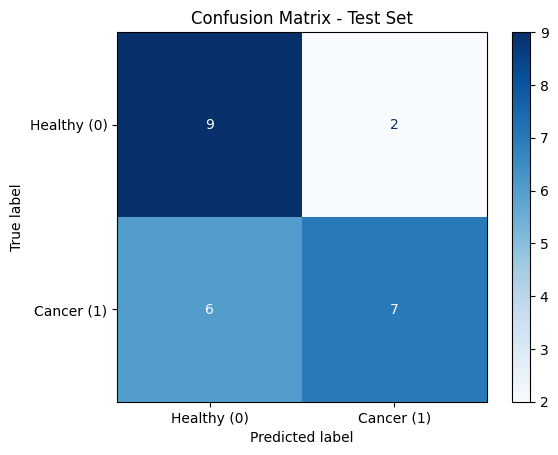

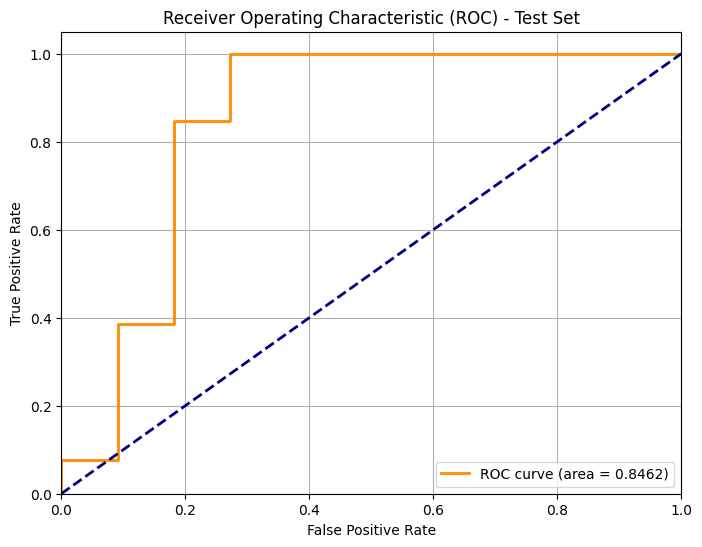

In [48]:
y_test_pred = final_model_pipeline.predict(X_test)
y_test_proba = final_model_pipeline.predict_proba(X_test)[:, 1] # Probabilities for the positive class (Cancer=1)

test_accuracy = accuracy_score(Y_test, y_test_pred)
test_auc = roc_auc_score(Y_test, y_test_proba)

print(f"\nFinal Model Performance on Test Set:")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test AUC: {test_auc:.4f}")

# You can also look at a confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve

conf_matrix = confusion_matrix(Y_test, y_test_pred)
print("\nConfusion Matrix on Test Set (TN, FP / FN, TP):")
print(conf_matrix)

disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=['Healthy (0)', 'Cancer (1)'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - Test Set")
plt.show()

# And plot the ROC curve for the test set
fpr, tpr, thresholds = roc_curve(Y_test, y_test_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {test_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) - Test Set')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

---
# 10. Save the Model

In [49]:
import joblib

model_filename = '../models/breast_cancer_coimbra_classification.pkl'
joblib.dump(final_model_pipeline, model_filename)
print(f"\nModel saved as:{model_filename}")

# To load it later:
# loaded_model = joblib.load(model_filename)
# predictions = loaded_model.predict(new_data)


Model saved as:../models/breast_cancer_coimbra_classification.pkl
